<a href="https://colab.research.google.com/github/Arjunanand717/Deep-learing-/blob/main/EXP2_PART_A_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PART B: PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS

In this section, we will train identical Artificial Neural Network (ANN) architectures using Sigmoid, Tanh, and ReLU activation functions. We will then record and compare their training accuracy, validation accuracy, training loss, validation loss, and the number of epochs required for convergence. The Fashion MNIST dataset will be used for this comparison.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape images to (num_samples, 784) for a dense network
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (60000, 784)
y_train shape: (60000,)
x_test shape: (10000, 784)
y_test shape: (10000,)


In [ ]:
def build_model(activation_function):
    model = keras.Sequential([
        keras.Input(shape=(784,)),
        layers.Dense(256, activation=activation_function, name=f"hidden_layer_1_{activation_function}"),
        layers.Dense(128, activation=activation_function, name=f"hidden_layer_2_{activation_function}"),
        layers.Dense(10, activation="softmax", name="output_layer") # Output layer for 10 classes
    ])
    return model

# Define activation functions to test
activation_functions = ['sigmoid', 'tanh', 'relu']

history = {}
epochs = 10 # Number of epochs for training
batch_size = 32

for act_fn in activation_functions:
    print(f"\nTraining model with {act_fn} activation function...")
    model = build_model(act_fn)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Use EarlyStopping for convergence
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=3,          # Stop if no improvement for 3 epochs
        restore_best_weights=True # Restore weights from the epoch with the best validation loss
    )

    hist = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2, # Use 20% of training data for validation
        callbacks=[early_stopping],
        verbose=0 # Set verbose to 0 to suppress output for cleaner logs
    )
    history[act_fn] = hist
    print(f"Training finished for {act_fn}. Best epoch: {early_stopping.best_epoch + 1}")

    # Evaluate the model on the test set
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test accuracy for {act_fn}: {test_acc:.4f}")
    print(f"Test loss for {act_fn}: {test_loss:.4f}")


Training model with sigmoid activation function...
Training finished for sigmoid. Best epoch: 10
Test accuracy for sigmoid: 0.8826
Test loss for sigmoid: 0.3265

Training model with tanh activation function...
Training finished for tanh. Best epoch: 5
Test accuracy for tanh: 0.8728
Test loss for tanh: 0.3482

Training model with relu activation function...
Training finished for relu. Best epoch: 9
Test accuracy for relu: 0.8823
Test loss for relu: 0.3386


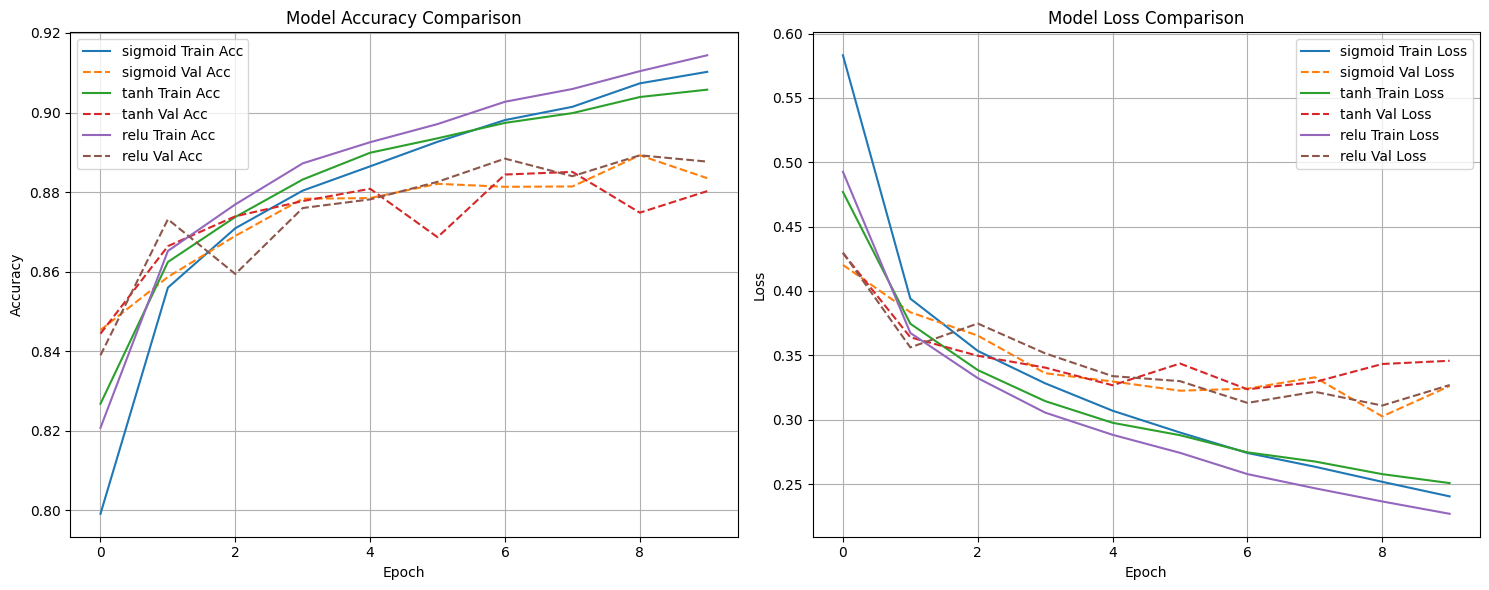

In [ ]:
plt.figure(figsize=(15, 6))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
for act_fn, hist in history.items():
    plt.plot(hist.history['accuracy'], label=f'{act_fn} Train Acc')
    plt.plot(hist.history['val_accuracy'], label=f'{act_fn} Val Acc', linestyle='--')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
for act_fn, hist in history.items():
    plt.plot(hist.history['loss'], label=f'{act_fn} Train Loss')
    plt.plot(hist.history['val_loss'], label=f'{act_fn} Val Loss', linestyle='--')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Analysis of Activation Function Performance

Based on the training and validation results, we can analyze the impact of different activation functions:

*   **Training Accuracy and Loss**: Observe how quickly each model's training accuracy increases and training loss decreases. Activation functions that lead to faster convergence typically show steeper curves.

*   **Validation Accuracy and Loss**: This is crucial for understanding how well the model generalizes to unseen data. A good activation function will lead to high validation accuracy and low validation loss without significant overfitting (where training metrics are much better than validation metrics).

*   **Number of Epochs for Convergence**: The `EarlyStopping` callback helps us identify how many epochs each model took to reach its best performance on the validation set. Activation functions that reach their optimal performance in fewer epochs are generally more efficient.

**Typical Observations (and what to look for in your plots):**

1.  **ReLU**: Often performs best and converges fastest. Its constant gradient (for positive inputs) helps avoid the vanishing gradient problem, leading to quicker learning and often higher overall accuracy. It is computationally efficient.

2.  **Tanh**: Usually performs better than Sigmoid, especially in deeper networks, because its output is zero-centered. This helps with gradient flow compared to Sigmoid. However, it can still suffer from vanishing gradients in its saturation regions.

3.  **Sigmoid**: Tends to perform the worst in deeper networks due to the severe vanishing gradient problem. Its output is always positive, which can lead to 'zig-zagging' gradient updates. It often shows slower learning and lower peak accuracy compared to Tanh and ReLU.

**Justification of Observations**:

*   **Vanishing Gradients**: Sigmoid and Tanh's saturation regions cause gradients to become very small, hindering learning in early layers of deep networks. ReLU's non-saturating nature for positive inputs largely mitigates this.
*   **Zero-centered Output**: Tanh's zero-centered output helps ensure that the average activation is close to zero, which can aid in faster convergence by reducing oscillations during gradient descent. Sigmoid's output is always positive, potentially leading to 'zig-zagging' gradient updates.
*   **Computational Cost**: ReLU is computationally simpler (max(0, x)) than Sigmoid or Tanh (which involve exponentials), contributing to faster training per epoch.

By comparing the plots and the final test accuracies, you should be able to clearly identify which activation function yielded the best results for this specific model and dataset, and understand *why* based on their inherent mathematical properties.